In [2]:
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from stable_baselines3 import SAC
import pandas as pd
import seaborn as sns
from models.pendulum.model import CD_Detector
import torch

import glob
from sklearn.metrics import precision_recall_curve, auc, f1_score
from algs.cd_poly import CDPolynomial

In [4]:
%pwd

'/Users/ljn/cd_project/notebooks'

In [81]:
n_eps=1000

def process_train():
    npz = np.load("../src/models/pendulum/train.npz")
    trip = npz["trip"]
    r = npz["rew"]
    param = npz["param"]

    cols = [f"s{i}" for i in range(4)] + [f"a{i}" for i in range(1)] + [f"ns{i}" for i in range(4)]
    df = pd.DataFrame(
        data=trip,
        columns=cols
    )
    df['step'] = np.array([[i for i in range(100)] for j in range(n_eps)]).flatten()
    df['ep'] = np.array([[i] * 100 for i in range(n_eps)]).flatten()
    df['r'] = r
    df['damp'] = np.concatenate([np.full((100,), param[i]) for i in range(n_eps)])

    df["cum_r"] = df.groupby('ep')['r'].cumsum()

    return df

def process_test():
    npz = np.load("../src/models/pendulum/test.npz")
    trip = npz["trip"]
    r = npz["rew"]
    param = npz["param"]

    cols = [f"s{i}" for i in range(4)] + [f"a{i}" for i in range(1)] + [f"ns{i}" for i in range(4)]
    df_te = pd.DataFrame(
        data=trip,
        columns=cols
    )
    df_te['step'] = np.array([[i for i in range(100)] for j in range(n_eps)]).flatten()
    df_te['ep'] = np.array([[i] * 100 for i in range(n_eps)]).flatten()
    df_te['r'] = r
    df_te['damp'] = np.concatenate([np.full((100,), param[i]) for i in range(n_eps)])

    df_te["cum_r"] = df_te.groupby('ep')['r'].cumsum()
    return df_te

In [83]:
df_tr, df_te = process_train(), process_test()

In [13]:
from sklearn.linear_model import LinearRegression

In [87]:
model = LinearRegression()
model.fit(df_tr.iloc[:,:5], df_tr.iloc[:,5:9])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [98]:
from sklearn.preprocessing import StandardScaler

In [100]:
df_tr[['res0', 'res1', 'res2', 'res3']] = df_tr.iloc[:,5:9] - model.predict(df_tr.iloc[:,:5])
df_te[['res0', 'res1', 'res2', 'res3']] = df_te.iloc[:,5:9] - model.predict(df_te.iloc[:,:5])

df_tr[['res0', 'res1', 'res2', 'res3']] = StandardScaler().fit_transform(df_tr[['res0', 'res1', 'res2', 'res3']] )
df_te[['res0', 'res1', 'res2', 'res3']] = StandardScaler().fit_transform(df_te[['res0', 'res1', 'res2', 'res3']] )

In [105]:
p = CDPolynomial(df_tr[[f'res{i}' for i in range(4)]].to_numpy(), degree=3, verbose=True)

Data monomials shape: torch.Size([100000, 35])
Moment matrix cond num: 9.348368e+08
Empirical mean of CD poly: 41.88394546508789


In [111]:
df_tr['cd'] = np.log(p(df_tr[[f'res{i}' for i in range(4)]].to_numpy()))
df_te['cd'] = np.log(p(df_te[[f'res{i}' for i in range(4)]].to_numpy()))

In [119]:
df_te['damp'].min()

0.807053000027991

In [127]:
fail = df_te.groupby('ep')['r'].min() == 0.0
fail_map = dict(zip(range(n_eps), fail))
df_te_fail = df_te[df_te['ep'].map(fail_map)]
df_te_succ = df_te[~df_te['ep'].map(fail_map)]

In [145]:
np.linalg.norm(df_tr[['res0','res1','res2','res3']], axis=1).mean()

1.4163402317810123

np.linalg.norm(df_te_succ[['res0','res1','res2','res3']], axis=1).mean()

In [152]:
np.linalg.norm(df_te_fail[['res0','res1','res2','res3']], axis=1).mean()

2.5734720986762967

<Axes: xlabel='step'>

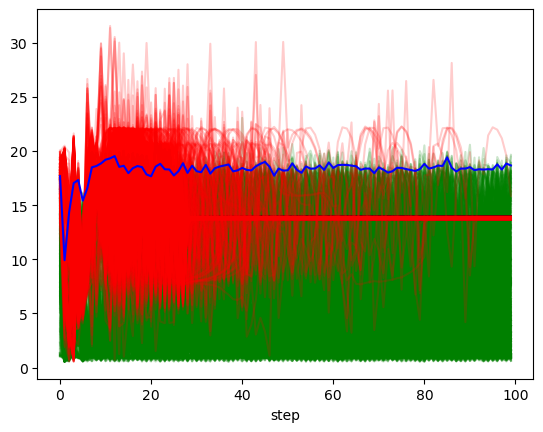

In [157]:
for i in df_te_succ['ep'].unique():
    plt.plot(range(100), df_te_succ[df_te_succ['ep'] == i]['cd'], color='green', alpha=0.2)

for i in df_te_fail['ep'].unique():
    plt.plot(range(100), df_te_fail[df_te_fail['ep'] == i]['cd'], color='red', alpha=0.2)

df_te_succ.groupby('step')['cd'].quantile(.99).plot(color='blue')